# Conformal cavity impedance validation

This notebook compares the legacy cell-based STL treatment with the new
point-mask-based conformal geometry pipeline for a cavity impedance simulation.

The same physical geometry, material properties and simulation parameters are
used for all cases. Only the STL classification method and the geometry
representation are varied.

The following STL classification methods are considered:

- `voxelize_rectilinear`
- `interior_points`
- `implicit_distance`

For each method, both

- `geometry_mode="legacy"` and
- `geometry_mode="conformal"`

are evaluated.

The purpose of this notebook is to investigate how the different geometry
representations affect the calculated longitudinal impedance and, in particular,
the resonance positions.

A central motivation for the point-based representation is to separate the
geometrical STL classification from the subsequent material assignment. In the
legacy implementation, different PyVista classification methods can lead to
different cell masks and therefore different numerical results. With the
point-mask-based pipeline, the STL geometry is first classified on the primal
grid points and the subsequent material representation is derived consistently
from these point masks.

The current conformal material treatment is still approximate and does not yet
use exact STL-grid intersection positions. Therefore, the conformal results are
not expected to be systematically more accurate than the legacy results. This
notebook is primarily intended to verify the consistency of the new geometry
pipeline and its dependence on the selected STL classification method.

In [2]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.signal import find_peaks

from wakis import GridFIT3D, SolverFIT3D, WakeSolver

## Geometry and simulation parameters

The numerical parameters below follow the existing 007 / 013 regression setup
closely so that the comparison remains representative of the current WAKIS tests.

`wakelength = 10 m` is intentionally retained because the purpose here is to
compare the impedance spectra and resonance positions. For quick development
checks it can temporarily be reduced.

In [3]:
# ------------------------------------------------------------------
# STL geometry
# ------------------------------------------------------------------
stl_dir = Path("..") / "tests" / "stl"
solid_cavity = stl_dir / "007_vacuum_cavity.stl"
solid_shell = stl_dir / "007_lossymetal_shell.stl"

stl_solids = {
    "cavity": str(solid_cavity),
    "shell": str(solid_shell),
}

# Keep the shell explicitly although the background is also PEC.
stl_materials = {
    "cavity": "vacuum",
    "shell": "pec",
}

solids = pv.read(str(solid_cavity)) + pv.read(str(solid_shell))
xmin, xmax, ymin, ymax, zmin, zmax = solids.bounds

# ------------------------------------------------------------------
# Mesh
# ------------------------------------------------------------------
Nx = 30
Ny = 30
Nz = 60

# ------------------------------------------------------------------
# Beam / wake parameters
# ------------------------------------------------------------------
sigmaz = 10e-2       # [m]
q = 1e-9             # [C]
beta = 1.0
xsource = 0.0
ysource = 0.0
xtest = 0.0
ytest = 0.0

wakelength = 40.0    # [m]
skip_cells = 20

# ------------------------------------------------------------------
# Boundary conditions
# ------------------------------------------------------------------
bc_low = ["pec", "pec", "pec"]
bc_high = ["pec", "pec", "pec"]

print("Geometry bounds:")
print(f"x: [{xmin:.6g}, {xmax:.6g}] m")
print(f"y: [{ymin:.6g}, {ymax:.6g}] m")
print(f"z: [{zmin:.6g}, {zmax:.6g}] m")
print(f"Grid: {Nx} x {Ny} x {Nz}")

Geometry bounds:
x: [-0.26, 0.26] m
y: [-0.26, 0.26] m
z: [-0.25, 0.55] m
Grid: 30 x 30 x 60


## Simulation helper

Each case gets its own result directory so the generated `Ez.h5` files do not
overwrite each other. The temporary results are stored below
`notebooks/_008_results/`.

These files should normally **not** be committed to Git.

In [5]:
results_root = Path("_008_results")
results_root.mkdir(parents=True, exist_ok=True)


def _frequency_axis(wake):
    """Return the impedance frequency axis using the available WakeSolver attribute."""
    for name in ("f", "freq", "frequency"):
        if hasattr(wake, name):
            return np.asarray(getattr(wake, name))
    raise AttributeError(
        "Could not find the WakeSolver frequency axis. "
        "Expected one of: wake.f, wake.freq, wake.frequency."
    )


def run_case(name, geometry_mode, stl_method, clean_results=True):
    print()
    print("=" * 78)
    print(f"Running case: {name}")
    print(f"geometry_mode = {geometry_mode}")
    print(f"stl_method    = {stl_method}")
    print("=" * 78)

    case_folder = results_root / name

    if clean_results and case_folder.exists():
        shutil.rmtree(case_folder)

    case_folder.mkdir(parents=True, exist_ok=True)

    grid = GridFIT3D(
        xmin,
        xmax,
        ymin,
        ymax,
        zmin,
        zmax,
        Nx,
        Ny,
        Nz,
        stl_solids=stl_solids,
        stl_materials=stl_materials,
        stl_method=stl_method,
        geometry_mode=geometry_mode,
        subpixel_smoothing=False,
        stl_scale=1.0,
        stl_rotate=[0, 0, 0],
        stl_translate=[0, 0, 0],
        verbose=1,
    )

    wake = WakeSolver(
        q=q,
        sigmaz=sigmaz,
        beta=beta,
        xsource=xsource,
        ysource=ysource,
        xtest=xtest,
        ytest=ytest,
        skip_cells=skip_cells,
        results_folder=str(case_folder) + "/",
        Ez_file=str(case_folder / "Ez.h5"),
    )

    solver = SolverFIT3D(
        grid,
        wake,
        bc_low=bc_low,
        bc_high=bc_high,
        use_stl=True,
        bg="pec",
        use_gpu=False,
    )

    solver.wakesolve(wakelength=wakelength)

    f = _frequency_axis(wake)
    Z = np.asarray(wake.Z)

    result = {
        "name": name,
        "geometry_mode": geometry_mode,
        "stl_method": stl_method,
        "grid": grid,
        "wake": wake,
        "solver": solver,
        "f": f,
        "Z": Z,
        "Zabs": np.abs(Z),
    }

    # Geometry diagnostics
    for key in stl_solids:
        cell_count = int(np.sum(np.asarray(grid.grid[key]).astype(bool)))

        if geometry_mode == "conformal":
            primal_count = int(np.sum(grid.primal_point_masks[key]))
            dual_count = int(np.sum(grid.dual_point_masks[key]))

            print(
                f"{key:>8s}: "
                f"{primal_count} primal points, "
                f"{cell_count} cell centers, "
                f"{dual_count} dual points"
            )
        else:
            print(f"{key:>8s}: {cell_count} legacy cells")

    return result

## Run the six cases

In [6]:
cases = {}

cases["legacy_voxelize"] = run_case(
    name="legacy_voxelize",
    geometry_mode="legacy",
    stl_method="voxelize_rectilinear",
)

cases["legacy_interior"] = run_case(
    name="legacy_interior",
    geometry_mode="legacy",
    stl_method="interior_points",
)

cases["legacy_implicit"] = run_case(
    name="legacy_implicit",
    geometry_mode="legacy",
    stl_method="implicit_distance",
)

cases["conformal_voxelize"] = run_case(
    name="conformal_voxelize",
    geometry_mode="conformal",
    stl_method="voxelize_rectilinear",
)

cases["conformal_interior"] = run_case(
    name="conformal_interior",
    geometry_mode="conformal",
    stl_method="interior_points",
)

cases["conformal_implicit"] = run_case(
    name="conformal_implicit",
    geometry_mode="conformal",
    stl_method="implicit_distance",
)


Running case: legacy_voxelize
geometry_mode = legacy
stl_method    = voxelize_rectilinear
Generating grid with 54000 mesh cells...
Importing STL solids...
 * Marking cells inside STL solid 'cavity'...
    * STL solid cavity: 12936 cells marked inside the solid.
 * Marking cells inside STL solid 'shell'...
    * STL solid shell: 6603 cells marked inside the solid.
Total grid initialization time: 0.173126220703125 s
Initializing Wakefield parameters...
Total solver initialization time: 5.5789947509765625e-05 s
Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=0.9993081933333331 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 7.1290774567883135 S/m
Calculating maximal stable timestep...
    * Simulation timestep: dt=1.505e-11 s
    * Total simulation time for wakelength=1.0 m: tmax=8.811e-09 s
    * Total number of timesteps for wakelength=1.0 m: Nt=585
Pre-computing...
U

100%|██████████| 9229/9229 [00:21<00:00, 424.35it/s]


Reading h5 file _008_results/legacy_voxelize/Ez.h5
Size of the h5 file: 0.04 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 81504/81504 [00:13<00:00, 5877.25it/s]


Elapsed time 13.868177890777588 s
Calculating transverse wake potential WPx, WPy...


...

Reading h5 file _008_results/conformal_implicit/Ez.h5
Size of the h5 file: 0.04 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 81504/81504 [00:13<00:00, 6203.16it/s]


Elapsed time 13.139819145202637 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 81504/81504 [00:00<00:00, 234085.30it/s]


Elapsed time 0.3486673831939697 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 13s
  cavity: 12973 primal points, 12328 cell centers, 12360 dual points
   shell: 6669 primal points, 5313 cell centers, 5385 dual points


## Comparison 1 — Legacy vs. conformal

Both simulations use **exactly the same**
`stl_method="voxelize_rectilinear"`.

This isolates the effect of changing the geometry/material representation from
the legacy cell-based pipeline to the new point-based conformal pipeline.

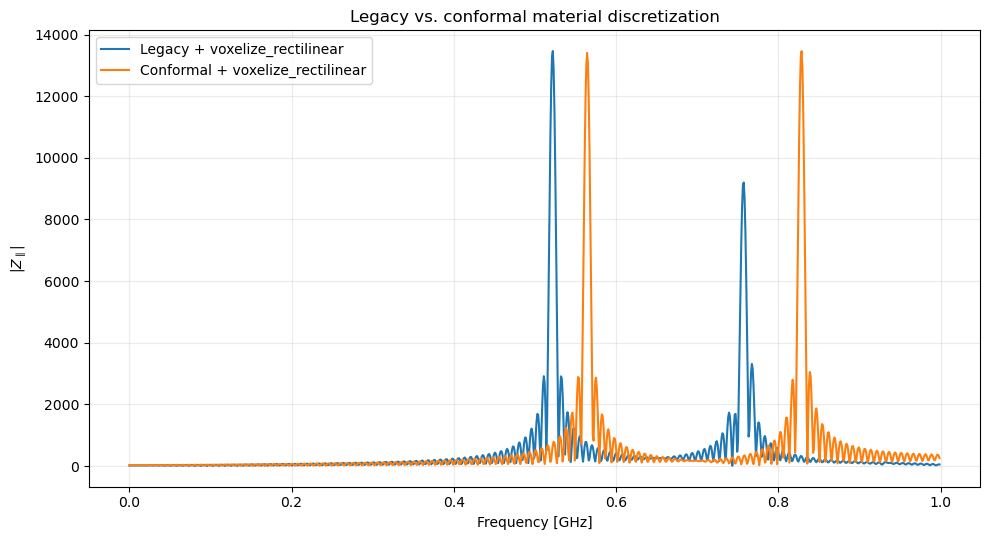

In [8]:
legacy = cases["legacy_voxelize"]
conformal = cases["conformal_voxelize"]

plt.figure(figsize=(10, 5.5))

plt.plot(
    legacy["f"] / 1e9,
    legacy["Zabs"],
    label="Legacy + voxelize_rectilinear",
)

plt.plot(
    conformal["f"] / 1e9,
    conformal["Zabs"],
    label="Conformal + voxelize_rectilinear",
)

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$|Z_\parallel|$")
plt.title("Legacy vs. conformal material discretization")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Comparison 2 — Conformal PyVista methods

This comparison keeps `geometry_mode="conformal"` fixed and changes only the
PyVista inside/outside classification method.

The purpose is to determine how sensitive the new conformal result is to the
underlying STL classification algorithm.

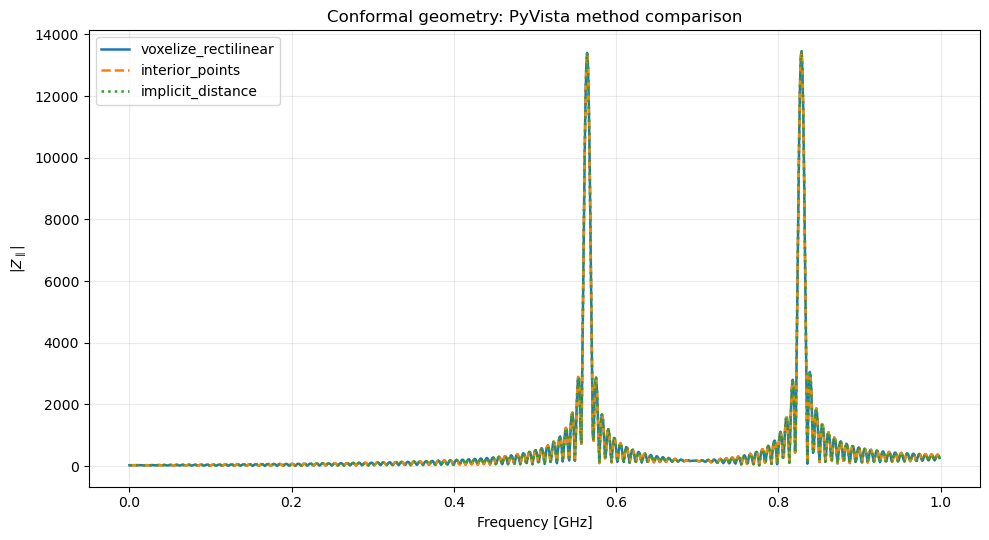

In [9]:
plt.figure(figsize=(10, 5.5))

styles = {
    "conformal_voxelize": "-",
    "conformal_interior": "--",
    "conformal_implicit": ":",
}

for key, label in [
    ("conformal_voxelize", "voxelize_rectilinear"),
    ("conformal_interior", "interior_points"),
    ("conformal_implicit", "implicit_distance"),
]:
    result = cases[key]

    plt.plot(
        result["f"] / 1e9,
        result["Zabs"],
        label=label,
        linestyle=styles[key],
        linewidth=1.8,
    )

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$|Z_\parallel|$")
plt.title("Conformal geometry: PyVista method comparison")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Comparison 3 — Legacy PyVista methods

This comparison keeps `geometry_mode="legacy"` fixed and changes only the
PyVista inside/outside classification method.

The purpose is to determine how sensitive the legacy result is to the
underlying STL classification algorithm and to compare this sensitivity with
the conformal geometry pipeline.

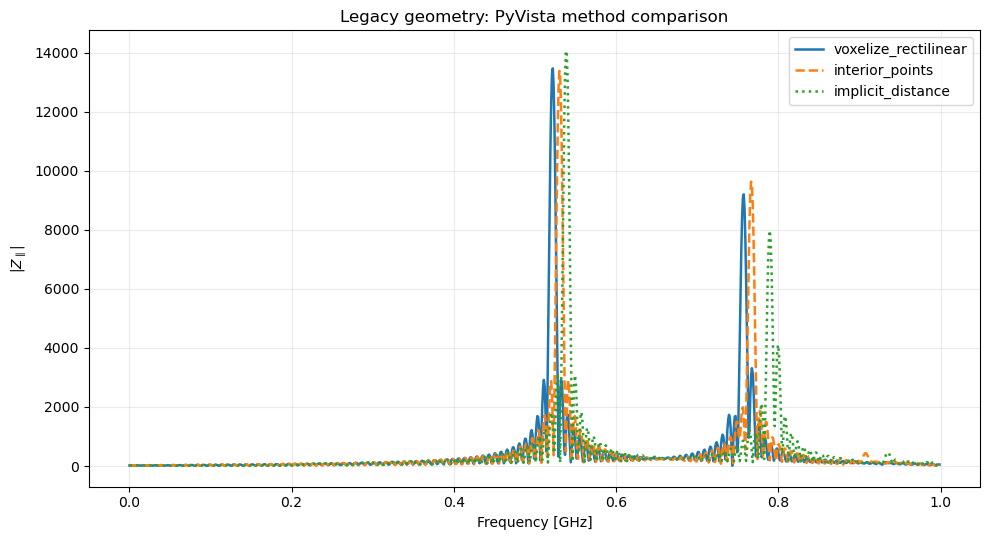

In [10]:
plt.figure(figsize=(10, 5.5))

styles = {
    "legacy_voxelize": "-",
    "legacy_interior": "--",
    "legacy_implicit": ":",
}

for key, label in [
    ("legacy_voxelize", "voxelize_rectilinear"),
    ("legacy_interior", "interior_points"),
    ("legacy_implicit", "implicit_distance"),
]:
    result = cases[key]

    plt.plot(
        result["f"] / 1e9,
        result["Zabs"],
        label=label,
        linestyle=styles[key],
        linewidth=1.8,
    )

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$|Z_\parallel|$")
plt.title("Legacy geometry: PyVista method comparison")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The impedance comparison shows a clear difference between the legacy
cell-based geometry treatment and the current point-mask-based conformal
approach. This is consistent with the edge-classification behavior observed in
the previous geometry diagnostic (notebook `007_pec_edge_classification_legacy_vs_conformal`), where both approaches produced different
discrete PEC/vacuum representations at material boundaries.

A second important observation is the sensitivity to the selected PyVista STL
classification method. For the legacy pipeline, the three methods lead to
noticeably different impedance curves. In contrast, the conformal cases produce
essentially identical results for all tested classification methods.

This suggests that at least part of the method dependence observed in the legacy
pipeline may originate from how the cell masks are derived and subsequently
translated into material properties, rather than from fundamental differences
between the PyVista inside/outside classification methods themselves.